In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [104]:
df_raw = pd.read_csv("data/icecube_public.txt",nrows=50000)

In [105]:
col_str = list(df_raw.columns)[0]
col_headers = col_str.split()
data_cols = ['MJD[days]','log10(E/GeV)','AngErr[deg]', 'RA[deg]', 'Dec[deg]']
df_raw[col_headers] = df_raw[col_str].str.split("\s+", expand=True)
df = df_raw[data_cols]

In [111]:
for i in data_cols:
    df[i] = pd.to_numeric(df[i],errors="coerce")
df_cleaned = df.dropna()

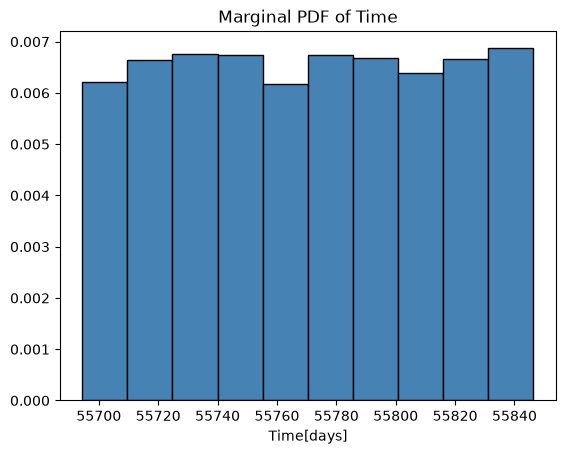

In [107]:
plt.hist(df["MJD[days]"], density=True,edgecolor = "black", color="steelblue")
plt.xlabel("Time[days]")
plt.title("Marginal PDF of Time")
plt.show()

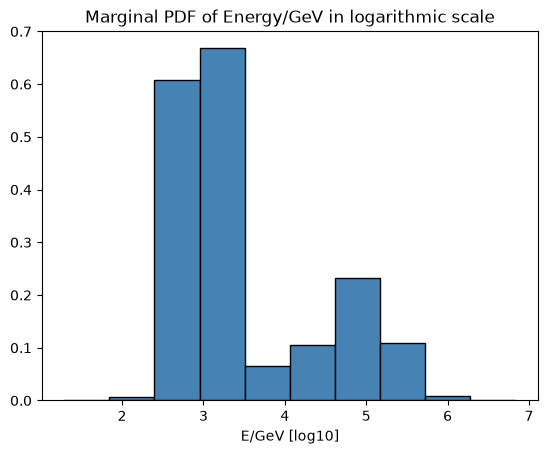

In [108]:
plt.hist(df["log10(E/GeV)"], density=True,color="steelblue",edgecolor = "black")
plt.xlabel("E/GeV [log10]")
plt.title("Marginal PDF of Energy/GeV in logarithmic scale")
plt.show()

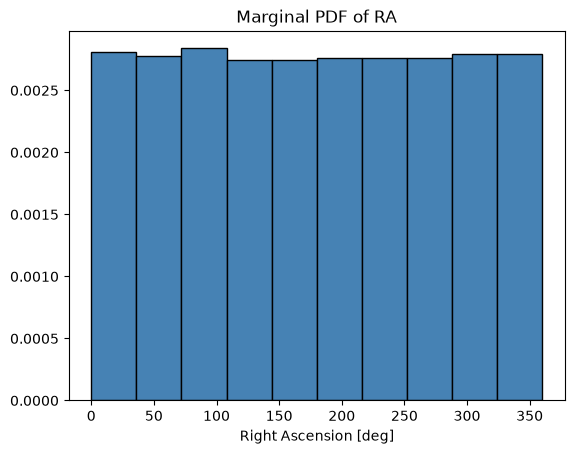

In [109]:
plt.hist(df["RA[deg]"], density=True,color="steelblue",edgecolor = "black")
plt.xlabel("Right Ascension [deg]")
plt.title("Marginal PDF of RA")
plt.show()

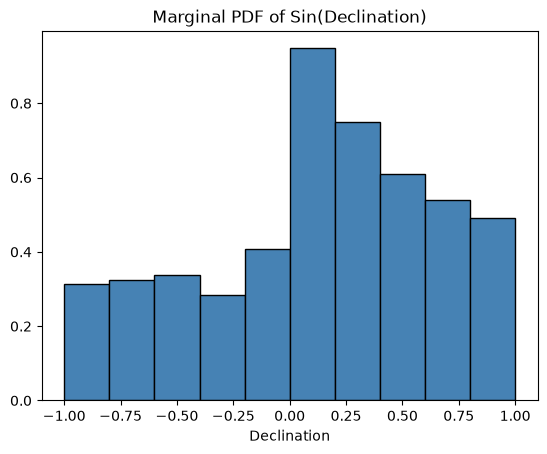

In [110]:
plt.hist(np.sin(df["Dec[deg]"]*np.pi/180), density=True,color="steelblue",edgecolor = "black")
plt.xlabel("Declination")
plt.title("Marginal PDF of Sin(Declination)")
plt.show()

We care about sin(declination) instead of declination because it represents a physical ratio of how much sky we see and in what direction relative to the radius of the earth.

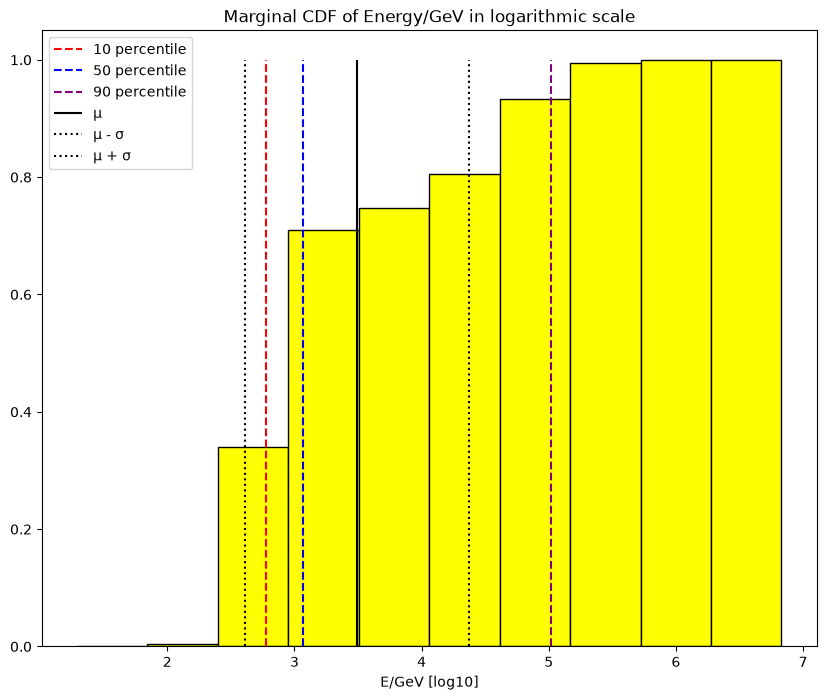

In [236]:
plt.figure(figsize=(10, 8))
for i,c in zip([10,50,90],["red","blue","purple"]):
    plt.vlines(np.percentile(df["log10(E/GeV)"],i), 
               ymin=0, ymax=1, colors=c, linestyle="dashed", label=f"{i} percentile")

plt.vlines(np.mean(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle="solid", label="\u03bc")
plt.vlines(np.mean(df["log10(E/GeV)"]) - np.std(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle=":", label="\u03bc - \u03C3")
plt.vlines(np.mean(df["log10(E/GeV)"]) + np.std(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle=":", label="\u03bc + \u03C3")

plt.hist(df["log10(E/GeV)"], density=True, color="yellow" ,edgecolor = "black", cumulative=True)

plt.xlabel("E/GeV [log10]")
plt.title("Marginal CDF of Energy/GeV in logarithmic scale")
plt.legend()
plt.show()

In [244]:
time = np.array(df["MJD[days]"])*86400
print(time)

[4.81199788e+09 4.81199809e+09 4.81199818e+09 ... 4.82511908e+09
 4.82511943e+09 4.82511953e+09]


In [255]:
time_diff = time[1:] - time[:-1]

[]
